<h1>2D Matter Geometry Creation</h1>

Generate a deterministic atomic interface geometry and save it as a CSV file.

In [9]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

resol = 160
plt.rcParams.update({
    "font.family": "serif",
    "axes.linewidth": 0.7,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
})

cwd = Path().resolve()
project_root = next(path for path in (cwd, *cwd.parents) if (path / "src").exists())
sys.path.append(str(project_root))

from src.fiber_geometry import (
    geometry_filename,
    plot_fiber_geometry,
    plot_slab_geometry,
    regular_disk_positions,
    regular_slab_positions,
    save_geometry_csv,
    slab_geometry_filename,
)


<h2>Disk geometry</h2>

In [2]:
L1 = 50.0
L2 = 5.0
N_A = 10
interface_radius = 1

geometry_dir = project_root / "2d_setup" / "geometries"
geometry_path = geometry_dir / geometry_filename(N_A, interface_radius)

atom_positions = regular_disk_positions(N_A, interface_radius)
geometry_path

PosixPath('/Users/romainpiron/Documents/NII_local/waveguide-qed-simulator/2d_setup/geometries/matter_geom_NA10_R1.csv')

<h2>Visualize and save</h2>

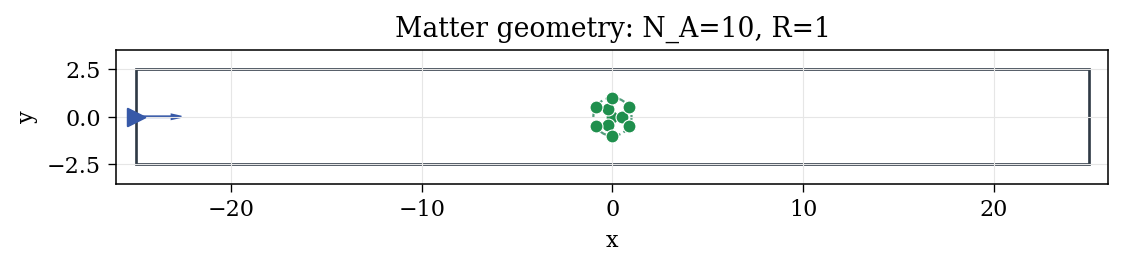

Saved geometry to: /Users/romainpiron/Documents/NII_local/waveguide-qed-simulator/2d_setup/geometries/matter_geom_NA10_R1.csv


In [3]:
fig, ax = plt.subplots(figsize=(8.0, 2.2), dpi=resol)
plot_fiber_geometry(
    ax,
    L1=L1,
    L2=L2,
    atom_positions=atom_positions,
    interface_radius=interface_radius,
    photon_position=(-L1 / 2, 0.0),
)
ax.set_title(f"Matter geometry: N_A={N_A}, R={interface_radius:g}")
plt.show()

save_geometry_csv(
    geometry_path,
    L1=L1,
    L2=L2,
    interface_radius=interface_radius,
    atom_positions=atom_positions,
)
print(f"Saved geometry to: {geometry_path}")

<h2>Slab geometry</h2>

Generate a deterministic vertical slab centered at the origin.

In [12]:
L1_slab = 50.0
L2_slab = 0.1
N_A_slab = 5
N_layer = 1

geometry_dir = project_root / "2d_setup" / "geometries"
slab_geometry_path = geometry_dir / slab_geometry_filename(N_A_slab, N_layer)

slab_atom_positions = regular_slab_positions(
    n_atoms=N_A_slab,
    n_layers=N_layer,
    L2=L2_slab,
)
slab_geometry_path

PosixPath('/Users/romainpiron/Documents/NII_local/waveguide-qed-simulator/2d_setup/geometries/matter_geom_NA5_NL1.csv')

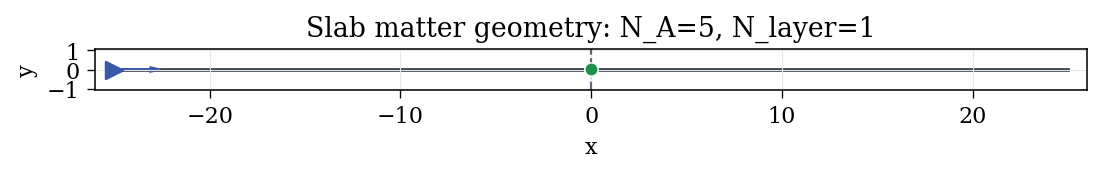

Saved slab geometry to: /Users/romainpiron/Documents/NII_local/waveguide-qed-simulator/2d_setup/geometries/matter_geom_NA5_NL1.csv


In [13]:
fig, ax = plt.subplots(figsize=(8.0, 2.2), dpi=resol)
plot_slab_geometry(
    ax,
    L1=L1_slab,
    L2=L2_slab,
    atom_positions=slab_atom_positions,
    n_layers=N_layer,
    photon_position=(-L1_slab / 2, 0.0),
)
ax.set_title(f"Slab matter geometry: N_A={N_A_slab}, N_layer={N_layer}")
plt.show()

save_geometry_csv(
    slab_geometry_path,
    L1=L1_slab,
    L2=L2_slab,
    interface_radius=np.nan,
    atom_positions=slab_atom_positions,
    n_layers=N_layer,
)
print(f"Saved slab geometry to: {slab_geometry_path}")